In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [2]:
def create_grid(size:int, density:float, ratio:float):
    """
        Creates a (size x size) grid,
        where (100 * density)% of the grid is occupied by agents,
        and (100 * ratio)% of the agents are of type A, and remaining type B
    """
    grid = np.zeros((size, size), dtype=int).flatten()
    agents = random.sample(
        range(len(grid)), 
        k = round(density * len(grid))
    )
    set_to_A = random.sample(agents, k = round(ratio * len(agents)))
    set_to_B = list(set(agents).difference(set_to_A))

    grid[set_to_A] = 1
    grid[set_to_B] = 2
    grid = grid.reshape((size, size))
    return grid

In [3]:
def get_neighbours(grid, row, col):
    n = grid.shape[0]
    
    row_min = max(0, row - 1)
    row_max = min(n - 1, row + 1)
    col_min = max(0, col - 1)
    col_max = min(n - 1, col + 1)
    
    nbhood = grid[row_min:row_max+1, col_min:col_max+1].copy()
    
    # Exclude the center cell itself
    center_row = row - row_min
    center_col = col - col_min
    nbhood = np.delete(nbhood.flatten(), center_row * nbhood.shape[1] + center_col)
    return nbhood

In [4]:
def is_happy(grid, row, col, threshold):
    agent_type = grid[row][col]
    if(agent_type == 0):
        raise ValueError("no agent at position")
    
    nbhood = get_neighbours(grid, row, col)
    like_me = sum(nbhood == agent_type)
    occupied = sum(nbhood != 0)
    if(not occupied): 
        return True
        
    return ((like_me / occupied) >= threshold)

In [5]:
def transform_to_happy_grid(grid, threshold):
    n = grid.shape[0]
    
    happiness_grid = np.empty((n, n), dtype=str)
    for row in range(n):
        for col in range(n):
            happiness_grid[row][col] = "E" if(grid[row][col] == 0) else ("H" if (is_happy(grid, row, col, threshold)) else "NH")

    return happiness_grid

In [6]:
def run_step(grid, threshold):
    n = grid.shape[0]

    unhappy_agents = []
    empty_cells = []
    for row in range(n):
        for col in range(n):
            if(grid[row][col] == 0):
                empty_cells.append((row, col))
                continue

            if(not is_happy(grid, row, col, threshold)):
                unhappy_agents.append((row, col))

    move_to_empty = random.sample(empty_cells, k=min(len(unhappy_agents), len(empty_cells)))
    for (new_address, agent) in zip(move_to_empty, unhappy_agents):
        grid[new_address[0]][new_address[1]] = grid[agent[0]][agent[1]]
        grid[agent[0]][agent[1]] = 0

    return (grid, len(unhappy_agents))

In [7]:
def similarity_index(grid):
    n = grid.shape[0]

    similarity = []
    for row in range(n):
        for col in range(n):
            if(grid[row][col] == 0):
                continue

            nbhood = get_neighbours(grid, row, col)
            occupied = sum(nbhood != 0)
            like_me = sum(nbhood == grid[row][col])
            sim_ind = 1 if(occupied == 0) else (like_me / occupied)
            similarity.append(sim_ind)

    return sum(similarity)/len(similarity)

In [8]:
grid_size = 70
grid_density = 0.9
grid_ratio = 0.5
grid_happy_threshold = 0.3

cmap = ListedColormap(["white", "blue", "red"])  # 0,1,2 colors

grid = create_grid(grid_size, grid_density, grid_ratio)
init_grid = grid.copy()
count, unhappy = 0, 1
while(count < 100 and unhappy > 0):
    grid, unhappy = run_step(grid, grid_happy_threshold)
    count += 1

final_grid = grid.copy()

print(f"Initial similarity index: {similarity_index(init_grid)}")
print(f"Final similarity index: {similarity_index(final_grid)}")

Initial similarity index: 0.49678328474246863
Final similarity index: 0.7522319403952036


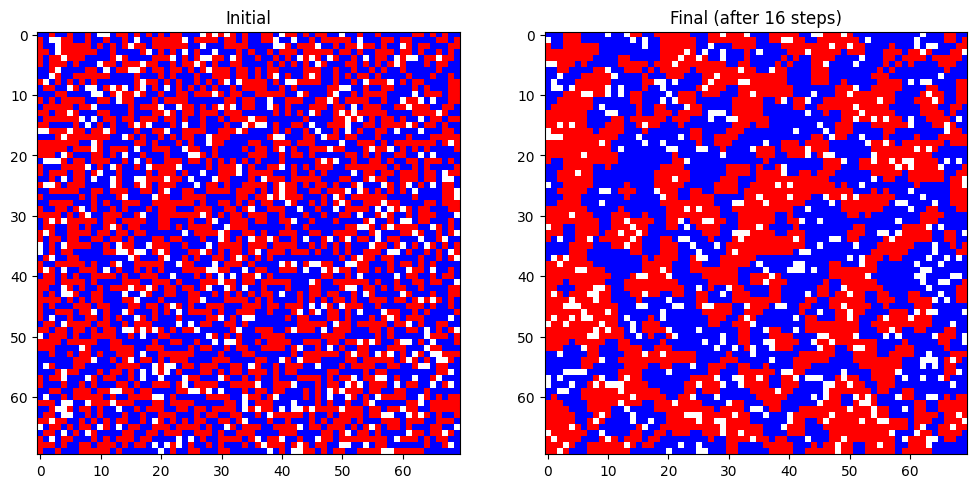

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(init_grid, cmap=cmap, vmin=0, vmax=2)
axes[0].set_title("Initial")
axes[1].imshow(final_grid, cmap=cmap, vmin=0, vmax=2)
axes[1].set_title(f"Final (after {count} steps)")
plt.show()